## Exploratory Data Analysis on the Fusarium project - dataset 1

### Importing the data

In [8]:
import pandas as pd

# Load the two CSV files
df1 = pd.read_csv("Greenhouse Pathogenicity Data_1.csv")
df2 = pd.read_csv("Greenhouse Pathogenicity Data_2.csv")

# Preview them
print("First dataset:")
display(df1.head())

print("Second dataset:")
display(df2.head())

First dataset:


,Unnamed: 0,Unnamed: 1,Isolate,R1,R2,R3
0,NaN,1,AN62503,4,4,NaN
1,NaN,2,AN62508,2,2,2.0
2,NaN,3,AN62509,5,5,3.0
3,NaN,4,AN62510,2,3,3.0
4,NaN,5,AN62512,4,4,4.0


Second dataset:


,Unnamed: 0,Unnamed: 1,R1,Unnamed: 3,Unnamed: 4,R2,Unnamed: 6,Unnamed: 7,R3,Unnamed: 9,Unnamed: 10,R4,Unnamed: 12,Unnamed: 13,R5,Unnamed: 15,Unnamed: 16
0,Group,Isolate,L,RT,%,L,RT,%,L,RT,%,L,RT,%,L,RT,%
1,J2,AT4-25-12,NaN,NaN,100,5,12,41.67,5,12,41.67,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,AN6-25-13,2,3,66.67,14,16,87.5,4,4,100,NaN,NaN,NaN,NaN,NaN,NaN
3,B,CW12-25-01,NaN,NaN,100,NaN,NaN,100,5,5,100,1,1,100,NaN,NaN,NaN
4,J4,GDY11-25-03,0,22,0,NaN,NaN,100.00,0,16,0.00,NaN,NaN,NaN,NaN,NaN,NaN


## Transforming data from wide form to long form to run analysis

In [9]:

# Dataset1 
import pandas as pd

# Load dataset 1
df = pd.read_csv("Greenhouse Pathogenicity Data_1.csv")

# Clean column names + remove unwanted columns
df.columns = df.columns.str.strip().str.replace("#", "", regex=False)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Reshape to long format
rep_cols = ["R1", "R2", "R3"]

df_long = df.melt(
    id_vars="Isolate",
    value_vars=rep_cols,
    var_name="Replicate",
    value_name="Score"
).dropna()

# Preview
display(df_long.head())

,Isolate,Replicate,Score
0,AN62503,R1,4.0
1,AN62508,R1,2.0
2,AN62509,R1,5.0
3,AN62510,R1,2.0
4,AN62512,R1,4.0


## ANOVA (Analysis of Variance analysis)


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip

=== ANOVA TABLE ===
                sum_sq     df         F        PR(>F)
C(Isolate)  138.236842   56.0  3.109511  1.482463e-07
Residual     90.500000  114.0       NaN           NaN

=== TUKEY POST-HOC TEST ===
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
  AN62503   AN62508     -2.0 0.9636 -5.3946  1.3946  False
  AN62503   AN62509   0.3333    1.0 -3.0613   3.728  False
  AN62503   AN62510  -1.3333    1.0  -4.728  2.0613  False
  AN62503   AN62512     -0.5    1.0 -3.5362  2.5362  False
  AN62503   ANG2513      0.0    1.0 -3.3946  3.3946  False
  AN62503   AT42503      1.0    1.0 -2.3946  4.3946  False
  AN62503   AT42505  -1.3333    1.0  -4.728  2.0613  False
  AN62503   AT42506      0.0    1.0 -3.3946  3.3946  False
  AN62503   AT42512      0.

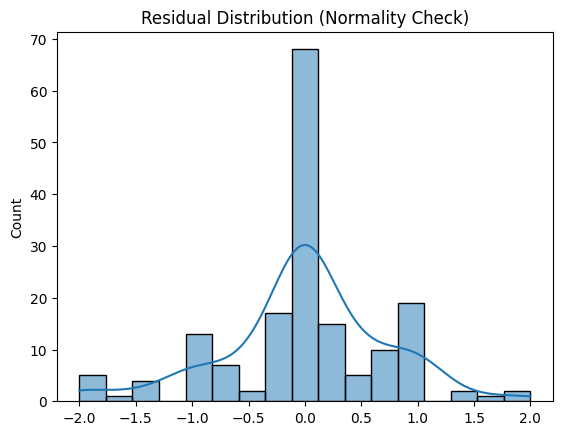

<Figure size 640x480 with 0 Axes>

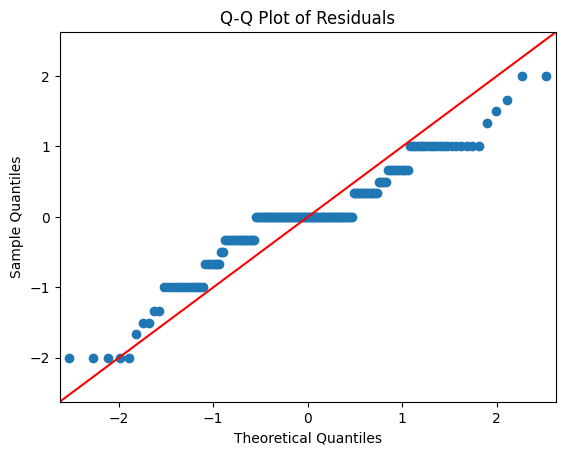

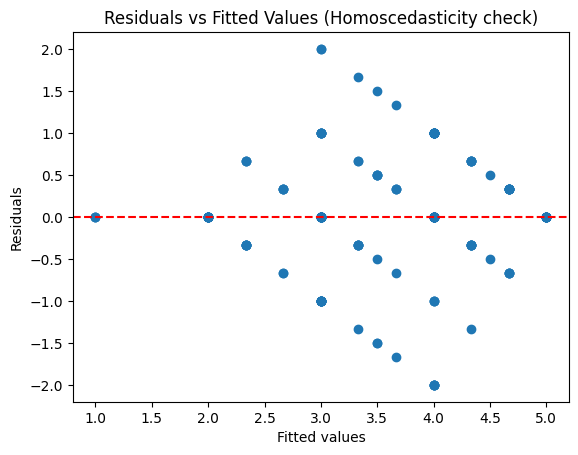

In [10]:
import sys
!{sys.executable} -m pip install scipy statsmodels seaborn
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# ONE-WAY ANOVA (Isolate effect)
# -----------------------------
model = ols('Score ~ C(Isolate)', data=df_long).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n=== ANOVA TABLE ===")
print(anova_table)

# -----------------------------
# Tukey HSD POST-HOC TEST
# -----------------------------
print("\n=== TUKEY POST-HOC TEST ===")
tukey = pairwise_tukeyhsd(
    endog=df_long["Score"],
    groups=df_long["Isolate"],
    alpha=0.05
)
print(tukey)

# -----------------------------
# RESIDUALS (for assumptions check)
# -----------------------------
residuals = model.resid

# -----------------------------
# 1. Residual plot
# -----------------------------
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Normality Check)")
plt.show()

# -----------------------------
# 2. Q-Q plot
# -----------------------------
plt.figure()
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

# -----------------------------
# 3. Residuals vs fitted values
# -----------------------------
fitted = model.fittedvalues

plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Homoscedasticity check)")
plt.show()

## Heat map


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


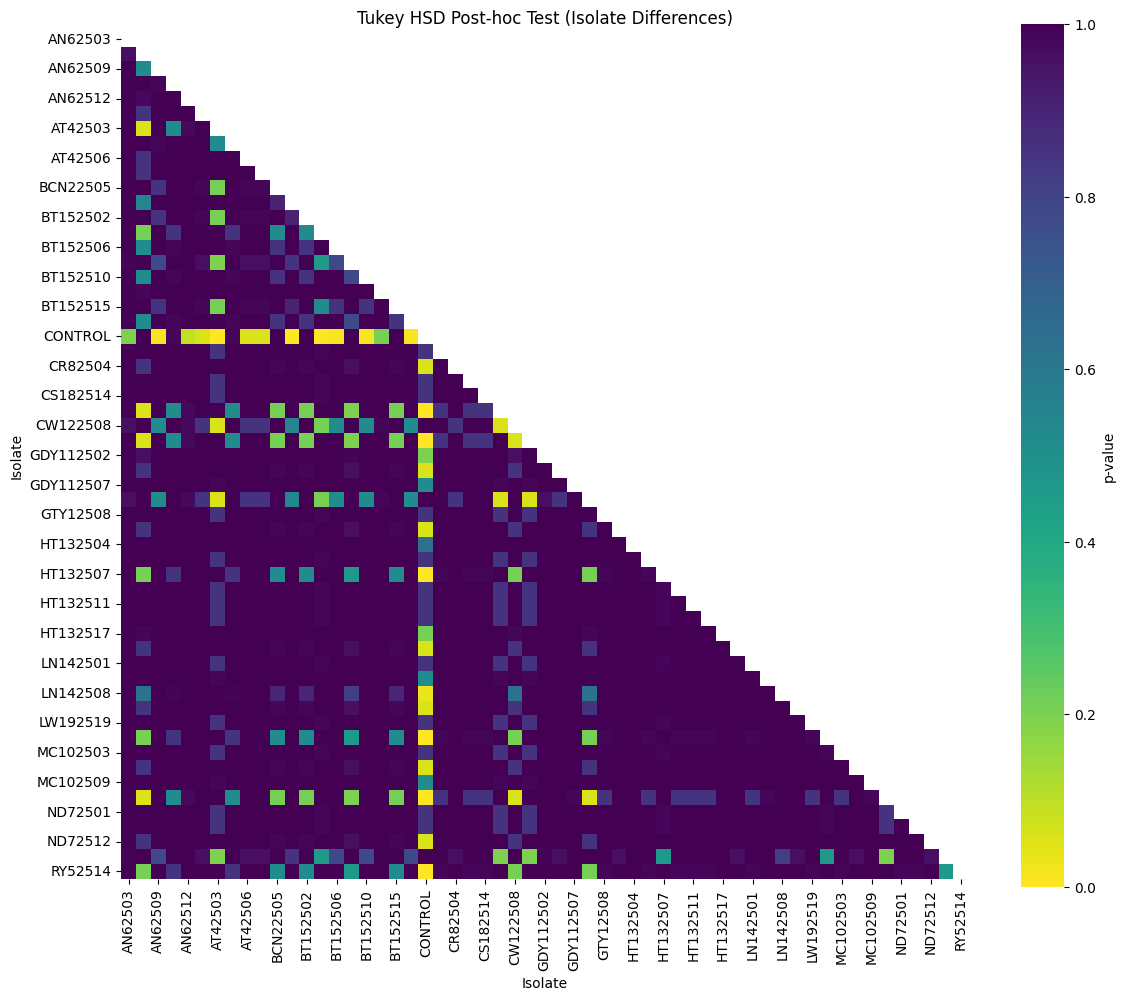

In [11]:
import sys
!{sys.executable} -m pip install scikit-posthocs
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Tukey post-hoc matrix (p-values)
# -----------------------------
posthoc = sp.posthoc_tukey(df_long, val_col="Score", group_col="Isolate")

# -----------------------------
# Optional: make it easier to read
# (mask diagonal + upper triangle)
# -----------------------------
import numpy as np

mask = np.triu(np.ones_like(posthoc, dtype=bool))

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(12, 10))

sns.heatmap(
    posthoc,
    mask=mask,
    cmap="viridis_r",
    vmin=0, vmax=1,
    square=True,
    cbar_kws={"label": "p-value"}
)

plt.title("Tukey HSD Post-hoc Test (Isolate Differences)")
plt.xlabel("Isolate")
plt.ylabel("Isolate")

plt.tight_layout()
plt.show()

## Dot plot

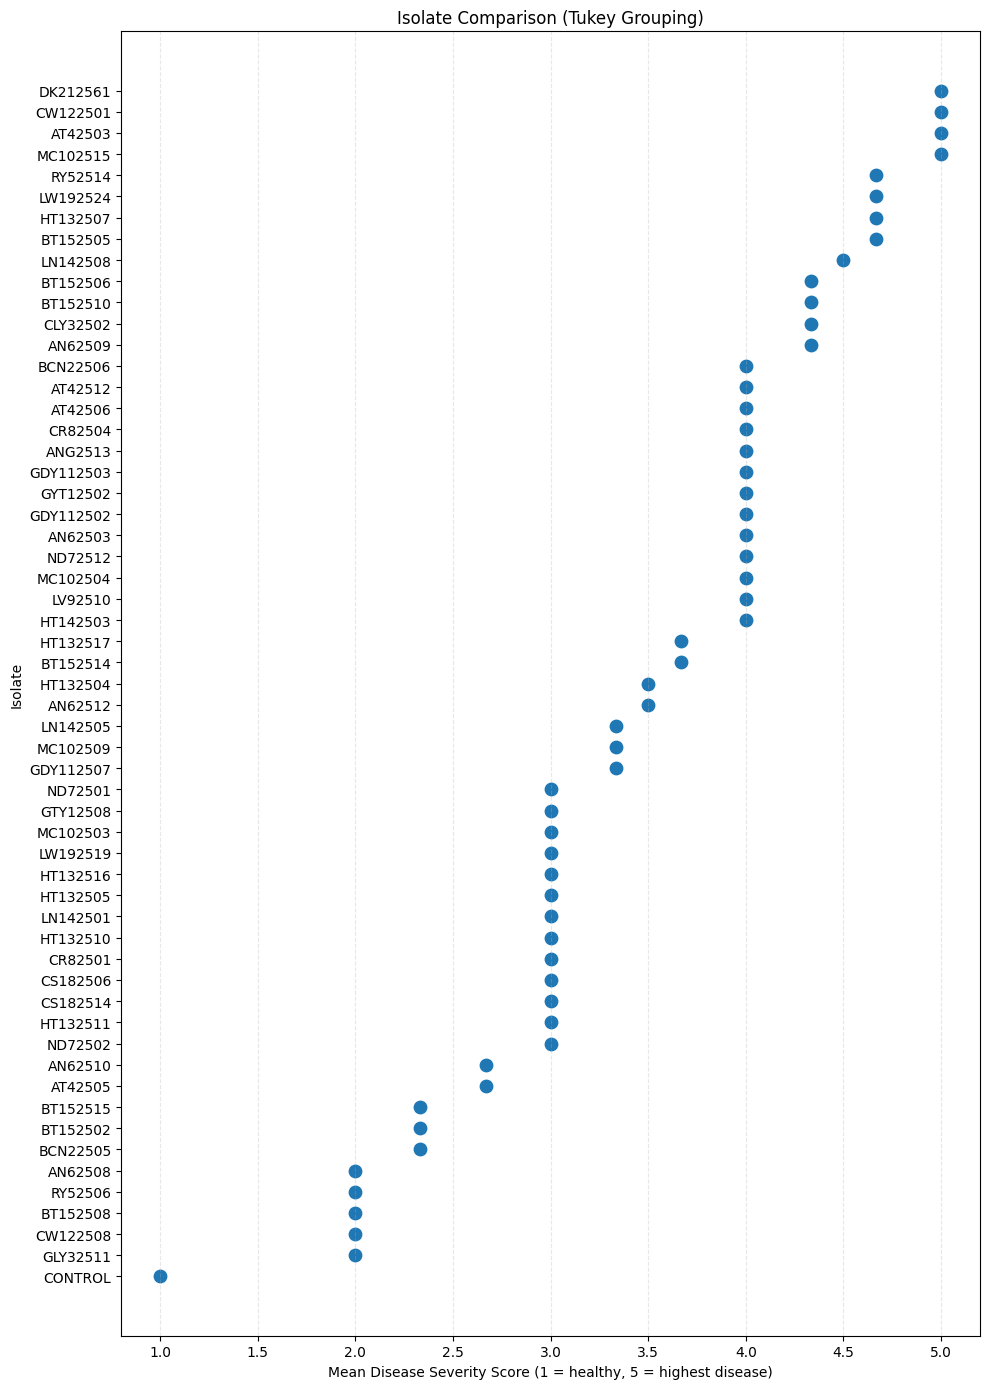

In [19]:
import matplotlib.pyplot as plt

# -----------------------------
# CREATE SUMMARY TABLE
# -----------------------------
summary = df_long.groupby("Isolate").agg(
    MeanScore=("Score", "mean")
).reset_index()

# FIX: add missing column
summary["Letter"] = ""

# -----------------------------
# Sort isolates
# -----------------------------
plot_df = summary.sort_values("MeanScore")

plt.figure(figsize=(10, 14))

# Dot plot
plt.scatter(
    plot_df["MeanScore"],
    plot_df["Isolate"],
    s=80
)

# Tukey letters (currently blank)
for _, row in plot_df.iterrows():
    plt.text(
        row["MeanScore"] + 0.0,
        row["Isolate"],
        row["Letter"],
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Isolate Comparison (Tukey Grouping)")
plt.xlabel("Mean Disease Severity Score (1 = healthy, 5 = highest disease)")
plt.ylabel("Isolate")

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()